 # NHEFS: does quitting smoking cause weight gain?



 This is real data, not synthetic — NHEFS, the dataset Hernán and Robins

 use throughout *Causal Inference: What If*. I picked it partly for that

 reason: I wanted a published number to check my own results against.



 Treatment is `qsmk` (quit smoking, yes/no), outcome is `wt82_71` (weight

 change in kg, 1971 to 1982). The obvious confounders are things like age,

 baseline weight, smoking intensity, exercise — people who quit aren't a

 random sample, so a raw comparison between quitters and non-quitters is

 going to be biased.

In [1]:
import numpy as np
import pandas as pd
from causaldata import nhefs
from econml.metalearners import TLearner, XLearner
from econml.grf import CausalForest
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.impute import SimpleImputer
%matplotlib inline
RNG = 42
np.random.seed(RNG)

CONFOUNDERS = [
    "age", "sex", "race", "education", "smokeintensity", "smokeyrs",
    "exercise", "active", "wt71", "ht",
]
TREATMENT = "qsmk"
OUTCOME = "wt82_71"


In [2]:
def load_data():
    df = nhefs.load_pandas().data
    cols = CONFOUNDERS + [TREATMENT, OUTCOME]
    df = df[cols].dropna(subset=[TREATMENT, OUTCOME]).copy()
    imputer = SimpleImputer(strategy="median")
    df[CONFOUNDERS] = imputer.fit_transform(df[CONFOUNDERS])
    return df

df = load_data()
print(f"N = {len(df)}, treated = {df[TREATMENT].sum()} ({df[TREATMENT].mean():.1%})")
df.head()


N = 1566, treated = 403.0 (25.7%)


,age,sex,race,education,smokeintensity,smokeyrs,exercise,active,wt71,ht,qsmk,wt82_71
0,42.0,0.0,1.0,1.0,30.0,29.0,2.0,0.0,79.04,174.1875,0.0,-10.093960
1,36.0,0.0,0.0,2.0,20.0,24.0,0.0,0.0,58.63,159.3750,0.0,2.604970
2,56.0,1.0,1.0,2.0,20.0,26.0,2.0,0.0,56.81,168.5000,0.0,9.414486
3,68.0,0.0,1.0,1.0,3.0,53.0,2.0,1.0,59.42,170.1875,0.0,4.990117
4,40.0,0.0,0.0,2.0,20.0,19.0,1.0,1.0,87.09,181.8750,0.0,4.989251


 ### The naive number — and why it's wrong



 Just subtracting the two group means, no adjustment at all. This is

 what you'd get from a purely correlational read of the data.

In [3]:
def naive_association(df):
    quit_mean = df.loc[df[TREATMENT] == 1, OUTCOME].mean()
    stay_mean = df.loc[df[TREATMENT] == 0, OUTCOME].mean()
    return quit_mean - stay_mean

naive = naive_association(df)
print(f"Naive: {naive:+.2f} kg")


Naive: +2.54 kg


 ### Adjusted estimates



 No train/test split this time — there's no ground truth to score

 against on real data, so I'm just using everything I've got to get the

 best estimate. Causal Forest also gives a 90% confidence interval per

 person, not just a point estimate, which matters if you actually want

 people to trust the number.

In [4]:
def estimate_cate(df):
    X = df[CONFOUNDERS].values
    T = df[TREATMENT].values
    Y = df[OUTCOME].values

    x_learner = XLearner(models=GradientBoostingRegressor(random_state=RNG))
    x_learner.fit(Y, T, X=X)
    tau_hat = x_learner.effect(X)

    cf = CausalForest(n_estimators=1000, random_state=RNG, honest=True)
    cf.fit(X, T, Y)
    tau_hat_cf = cf.predict(X).flatten()
    lb, ub = cf.predict_interval(X, alpha=0.1)

    out = df.copy()
    out["tau_hat_xlearner"] = tau_hat
    out["tau_hat_causalforest"] = tau_hat_cf
    out["tau_hat_cf_lower90"] = lb.flatten()
    out["tau_hat_cf_upper90"] = ub.flatten()
    return out, x_learner, cf

out, x_learner, cf = estimate_cate(df)
ate_x = out["tau_hat_xlearner"].mean()
ate_cf = out["tau_hat_causalforest"].mean()
print(f"X-learner: {ate_x:+.2f} kg")
print(f"Causal Forest: {ate_cf:+.2f} kg")
print(f"Gap vs naive: {abs(naive - ate_cf):.2f} kg — this is roughly the confounding bias removed by adjusting")


/Users/mebinrahman/anaconda3/envs/causal-ml/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


X-learner: +3.48 kg
Causal Forest: +3.03 kg
Gap vs naive: 0.49 kg — this is roughly the confounding bias removed by adjusting


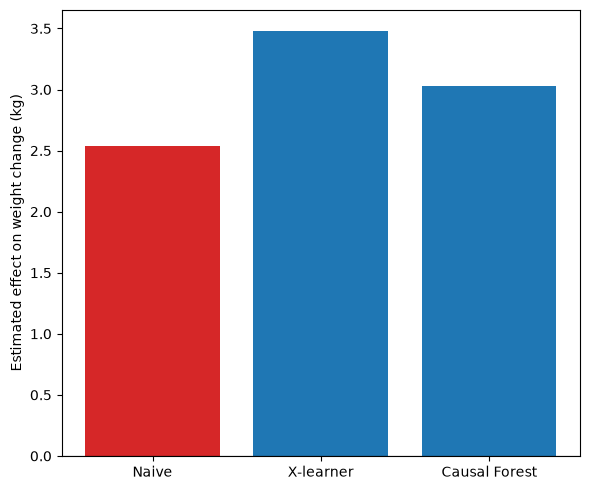

In [5]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6, 5))
methods = ["Naive", "X-learner", "Causal Forest"]
values = [naive, ate_x, ate_cf]
ax.bar(methods, values, color=["#d62728", "#1f77b4", "#1f77b4"])
ax.set_ylabel("Estimated effect on weight change (kg)")
ax.axhline(0, color="black", linewidth=0.8)
plt.tight_layout()
plt.show()


 ### Does the effect vary across people?



 One ATE number hides a lot. Splitting by smoking intensity and age to

 see if some groups see a bigger effect than others.

In [6]:
out["smoke_tercile"] = pd.qcut(out["smokeintensity"], 3, labels=["low", "mid", "high"])
print(out.groupby("smoke_tercile")["tau_hat_causalforest"].mean())

out["age_group"] = pd.cut(out["age"], bins=[0, 40, 55, 100], labels=["<=40", "41-55", "56+"])
print(out.groupby("age_group")["tau_hat_causalforest"].mean())


smoke_tercile
low     2.703975
mid     3.119707
high    3.309064
Name: tau_hat_causalforest, dtype: float64
age_group
<=40     2.976666
41-55    3.468442
56+      2.189837
Name: tau_hat_causalforest, dtype: float64


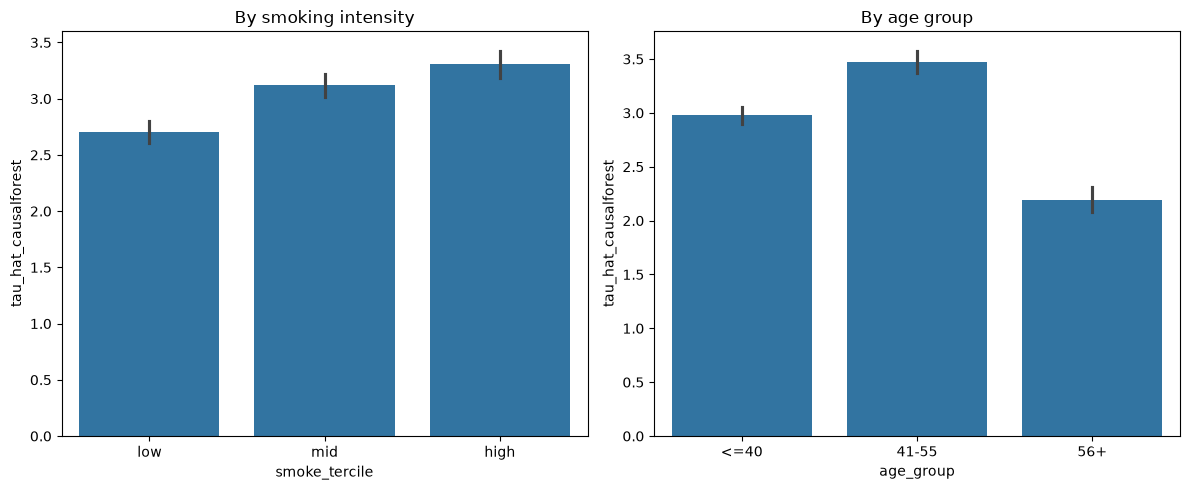

In [7]:
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.barplot(data=out, x="smoke_tercile", y="tau_hat_causalforest", ax=axes[0])
axes[0].set_title("By smoking intensity")
sns.barplot(data=out, x="age_group", y="tau_hat_causalforest", ax=axes[1])
axes[1].set_title("By age group")
plt.tight_layout()
plt.show()


In [8]:
out.to_csv("results_nhefs_cate.csv", index=False)


 Heavier smokers see a bigger effect from quitting (2.7 kg at the low

 end, 3.3 at the high end) — plausibly a stronger metabolic rebound, but

 that's my interpretation, not something the data proves on its own. Age

 is messier: the 41-55 group shows the biggest effect, 56+ the smallest,

 and I don't have a confident story for why — could be real, could partly

 be a smaller sample in that bin. Worth being upfront about that rather

 than making up an explanation.



 The adjusted numbers (3.0-3.5 kg) land close to the ~3.5 kg Hernán and

 Robins report in the book, which was a genuinely useful check that I

 hadn't messed up the pipeline somewhere.